### Импорт библиотек и базовые настройки

После установки зависимостей импортируем библиотеки для загрузки данных, визуализации, baseline-модели и DistilBERT.  
Также фиксируем random seed, чтобы результаты были воспроизводимыми.

In [19]:
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
from datasets import Dataset, DatasetDict
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Импорты успешно выполнены.")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Импорты успешно выполнены.
PyTorch version: 2.11.0+cu130
CUDA available: False


### Загрузка датасета BBC из папок

Теперь загрузим тексты новостей из структуры папок `bbc`, где каждая папка соответствует отдельному классу.  
В результате сформируем единый DataFrame с двумя основными колонками: `text` и `label`, чтобы дальше удобно выполнять EDA, обучение моделей и инференс.

In [20]:
DATA_DIR = Path("bbc")

EXPECTED_CLASSES = ["business", "entertainment", "politics", "sport", "tech"]

def load_bbc_dataset(data_dir: Path, expected_classes: list[str]) -> pd.DataFrame:
    records = []
    
    if not data_dir.exists():
        raise FileNotFoundError(
            f"Папка {data_dir} не найдена. Проверь путь к датасету."
        )
    
    for class_name in expected_classes:
        class_dir = data_dir / class_name
        
        if not class_dir.exists():
            print(f"Предупреждение: папка класса '{class_name}' не найдена, пропускаем.")
            continue
        
        txt_files = sorted(class_dir.glob("*.txt"))
        
        for file_path in txt_files:
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read().strip()
            
            records.append(
                {
                    "file_name": file_path.name,
                    "label": class_name,
                    "text": text
                }
            )
    
    df = pd.DataFrame(records)
    return df

df = load_bbc_dataset(DATA_DIR, EXPECTED_CLASSES)

print("Размер датасета:", df.shape)
print("\nКолонки:", df.columns.tolist())
print("\nПервые строки:")
display(df.head())

Размер датасета: (2221, 3)

Колонки: ['file_name', 'label', 'text']

Первые строки:


,file_name,label,text
0,001.txt,business,Ad sales boost Time Warner profit\n\nQuarterly...
1,002.txt,business,Dollar gains on Greenspan speech\n\nThe dollar...
2,003.txt,business,Yukos unit buyer faces loan claim\n\nThe owner...
3,004.txt,business,High fuel prices hit BA's profits\n\nBritish A...
4,005.txt,business,Pernod takeover talk lifts Domecq\n\nShares in...


На этом шаге мы перевели исходную файловую структуру в табличный формат, удобный для анализа и машинного обучения.  

### Проверка найденных классов

Дополнительно убедимся, что все ожидаемые категории действительно были загружены.  

In [21]:
print("Уникальные классы в датасете:", sorted(df["label"].unique()))
print("\nКоличество документов по классам:")
display(df["label"].value_counts().sort_index())

Уникальные классы в датасете: ['business', 'entertainment', 'politics', 'sport', 'tech']

Количество документов по классам:


label
business         506
entertainment    386
politics         417
sport            511
tech             401
Name: count, dtype: int64

Загрузка корректная: в датасете присутствуют все 5 классов, а распределение по ним выглядит правдоподобно для корпуса `BBC`, где классы `sport` и `business` немного крупнее, чем `entertainment` и `tech`.

### Первичный анализ данных

На этом этапе выполним базовый разведочный анализ датасета.  
Наша задача — проверить размер набора данных, наличие пропусков, посмотреть примеры текстов, распределение классов и длину документов.

In [22]:
print("Размер датасета:", df.shape)
print("\nПропуски по столбцам:")
display(df.isna().sum())

print("\nУникальные классы:")
print(sorted(df["label"].unique()))

print("\nКоличество документов по классам:")
display(df["label"].value_counts().sort_index())

print("\nПримеры текстов по одному документу из каждого класса:\n")
for class_name in sorted(df["label"].unique()):
    sample_text = df.loc[df["label"] == class_name, "text"].iloc[0]
    print("=" * 120)
    print(f"Класс: {class_name}")
    print(sample_text[:700])
    print()

Размер датасета: (2221, 3)

Пропуски по столбцам:


file_name    0
label        0
text         0
dtype: int64


Уникальные классы:
['business', 'entertainment', 'politics', 'sport', 'tech']

Количество документов по классам:


label
business         506
entertainment    386
politics         417
sport            511
tech             401
Name: count, dtype: int64


Примеры текстов по одному документу из каждого класса:

Класс: business
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.

Time Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than 

Класс: entertainment
Gallery unveils interactive tree

A Christmas tree that can receive text messages has been unveiled at London's Tate Britain art gallery.

The spruce has an antenna which can receive Bluetooth texts sent 

### Визуализация распределения классов

Построим столбчатую диаграмму, чтобы визуально оценить распределение документов по категориям.

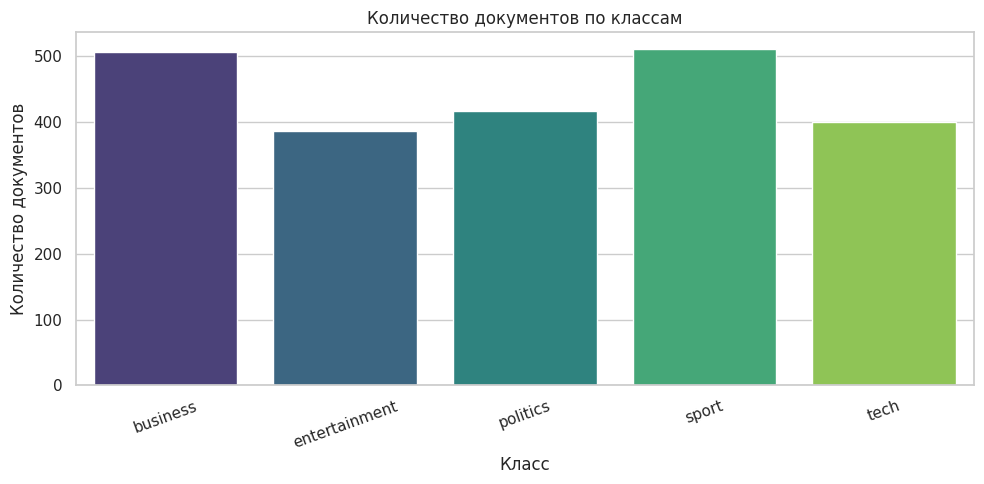

In [23]:
class_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="viridis", legend=False)
plt.title("Количество документов по классам")
plt.xlabel("Класс")
plt.ylabel("Количество документов")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Анализ длины текстов

Теперь добавим признаки длины текста в символах и словах, а затем посмотрим на их распределение.  
Это пригодится позже при выборе параметров предобработки и при настройке DistilBERT.

,count,mean,std,min,25%,50%,75%,max
text_length_chars,2221.0,2262.511932,1364.314883,502.0,1446.0,1960.0,2803.0,25484.0
text_length_words,2221.0,383.755516,238.211990,89.0,245.0,331.0,471.0,4432.0


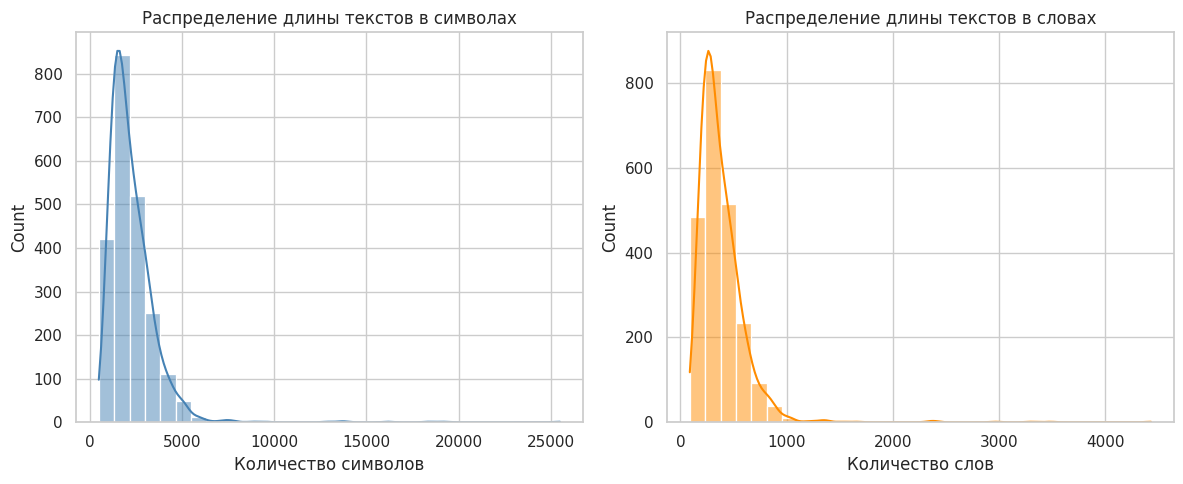

In [24]:
df["text_length_chars"] = df["text"].apply(len)
df["text_length_words"] = df["text"].apply(lambda x: len(x.split()))

display(df[["text_length_chars", "text_length_words"]].describe().T)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["text_length_chars"], bins=30, kde=True, color="steelblue")
plt.title("Распределение длины текстов в символах")
plt.xlabel("Количество символов")

plt.subplot(1, 2, 2)
sns.histplot(df["text_length_words"], bins=30, kde=True, color="darkorange")
plt.title("Распределение длины текстов в словах")
plt.xlabel("Количество слов")

plt.tight_layout()
plt.show()

### Средняя длина текста по классам

Дополнительно сравним среднюю длину текстов в разных классах.  
Это поможет понять, различаются ли категории не только по содержанию, но и по объёму статей.

,text_length_chars,text_length_words
label,,
business,1976.30,327.19
entertainment,1927.59,330.62
politics,2683.09,453.97
sport,1896.31,329.26
tech,2975.36,502.70


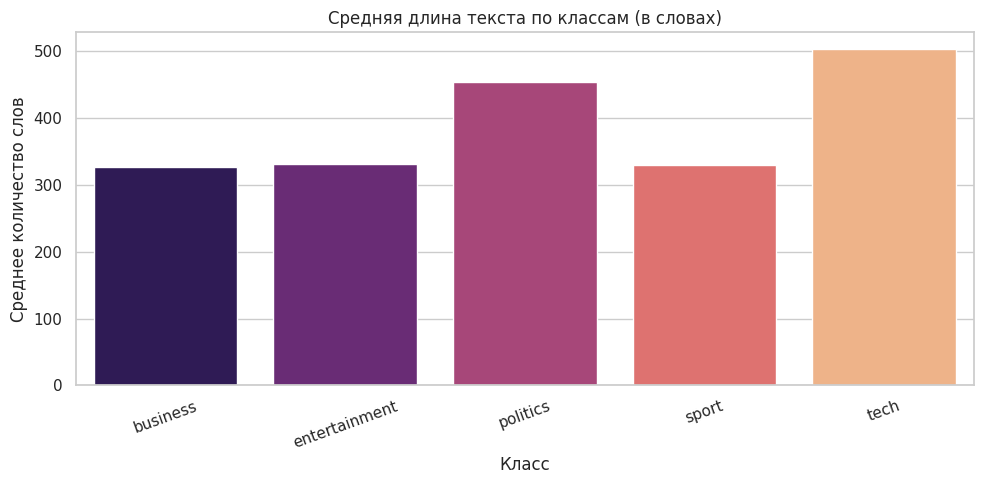

In [25]:
length_by_class = (
    df.groupby("label")[["text_length_chars", "text_length_words"]]
      .mean()
      .round(2)
      .sort_index()
)

display(length_by_class)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=length_by_class.reset_index(),
    x="label",
    y="text_length_words",
    hue="label",
    palette="magma",
    legend=False
)
plt.title("Средняя длина текста по классам (в словах)")
plt.xlabel("Класс")
plt.ylabel("Среднее количество слов")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

По результатам первичного анализа видно, что датасет содержит все пять требуемых классов новостей и не имеет критических проблем со структурой данных.  
Распределение документов по категориям является относительно сбалансированным: классы `business`, `sport`, `politics`, `tech` и `entertainment` представлены сопоставимым числом текстов, поэтому задача многоклассовой классификации не осложняется сильным дисбалансом.

Примеры документов подтверждают, что тексты действительно соответствуют своим тематикам: бизнес-новости описывают компании и финансовые показатели, политические материалы связаны с государственными инициативами, спортивные — с соревнованиями и спортсменами, а технологические — с ИТ и инновациями.  
Это означает, что в корпусе присутствуют содержательные тематические различия, которые модель сможет использовать при классификации.

Анализ длины текстов показал, что медианная длина документа составляет около 1960 символов и 331 слово, однако в распределении заметен длинный правый хвост.  
Это говорит о том, что в наборе есть как типичные по размеру статьи, так и существенно более длинные материалы, что особенно важно учитывать на этапе работы с DistilBERT из-за ограничения на длину входной последовательности.

Средняя длина текстов различается по классам: наиболее длинные статьи наблюдаются в категориях `tech` и `politics`, тогда как `business`, `entertainment` и `sport` в среднем короче.  
Такую особенность полезно зафиксировать в аналитической части ноутбука, поскольку она помогает лучше понять структуру корпуса и потенциальные различия в сложности классификации между классами.

### Подготовка текста для baseline-модели

Теперь подготовим тексты для классического baseline-подхода.  
Для моделей на основе TF-IDF обычно достаточно аккуратной очистки: приведение к нижнему регистру, удаление лишних символов, цифр и лишних пробелов.

In [26]:
nltk.download("stopwords")

english_stopwords = set(stopwords.words("english"))

def clean_text_for_classic_ml(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\n|\r|\t", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\b[a-z]\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["text"].apply(clean_text_for_classic_ml)

print("Примеры исходного и очищенного текста:\n")

for i in range(3):
    print("=" * 120)
    print(f"Пример {i + 1} — класс: {df.iloc[i]['label']}")
    print("\nИсходный текст:")
    print(df.iloc[i]["text"][:500])
    print("\nОчищенный текст:")
    print(df.iloc[i]["text_clean"][:500])
    print()

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/dovzhuk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Примеры исходного и очищенного текста:

Пример 1 — класс: business

Исходный текст:
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.

Time W

Очищенный текст:
ad sales boost time warner profit quarterly profits at us media giant timewarner jumped to bn for the three months to december from year earlier the firm which is now one of the biggest investors in google benefited from sales of high speed internet connections and higher advert sales timewarner said fourth quarter sales rose to bn from bn its profits were buoyed by one off gains which offset p

### Проверка качества очистки

После очистки важно убедиться, что тексты не превратились в пустые строки и что основное содержательное ядро документа сохранилось.  
Дополнительно проверим длину очищенных текстов.

In [27]:
df["clean_word_count"] = df["text_clean"].apply(lambda x: len(x.split()))

print("Статистика по длине очищенных текстов:")
display(df["clean_word_count"].describe())

print("\nКоличество пустых текстов после очистки:")
print((df["text_clean"].str.len() == 0).sum())

print("\nПервые 5 очищенных текстов:")
display(df[["label", "text_clean"]].head())

Статистика по длине очищенных текстов:


count    2221.000000
mean      369.340387
std       229.142615
min        87.000000
25%       236.000000
50%       319.000000
75%       454.000000
max      4282.000000
Name: clean_word_count, dtype: float64


Количество пустых текстов после очистки:
0

Первые 5 очищенных текстов:


,label,text_clean
0,business,ad sales boost time warner profit quarterly pr...
1,business,dollar gains on greenspan speech the dollar ha...
2,business,yukos unit buyer faces loan claim the owners o...
3,business,high fuel prices hit ba profits british airway...
4,business,pernod takeover talk lifts domecq shares in uk...


Предобработка текста для baseline-модели выполнена успешно.  
После очистки тексты сохранили основную смысловую информацию: в них остались ключевые слова, названия компаний, стран, событий и другие содержательные признаки, которые важны для тематической классификации.

Количество пустых документов после очистки равно нулю, а значит, ни один текст не был испорчен слишком агрессивной фильтрацией.  
Это важный промежуточный контроль качества, потому что потеря текстов на этапе preprocessing может ухудшить обучение модели и исказить распределение классов.

По статистике длины очищенных текстов видно, что корпус остаётся достаточно информативным: медианная длина составляет 319 слов, а средняя — около 369 слов.  
Следовательно, baseline-модель будет обучаться не на коротких фрагментах, а на полноценных новостных текстах, что повышает шансы на хорошее качество классификации.

### Разбиение данных на train, validation и test

Теперь разделим корпус на обучающую, валидационную и тестовую выборки.  
Такое разбиение нужно для корректной оценки качества: модель обучается на train, промежуточно проверяется на validation, а итоговая оценка выполняется на test.

In [28]:
X = df["text_clean"]
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Размеры выборок:")
print(f"Train: {X_train.shape[0]}")
print(f"Validation: {X_valid.shape[0]}")
print(f"Test: {X_test.shape[0]}")

Размеры выборок:
Train: 1554
Validation: 333
Test: 334


### Проверка распределения классов по выборкам

После разбиения важно убедиться, что стратификация сработала корректно и доли классов в разных подвыборках остались примерно одинаковыми.

In [29]:
train_dist = y_train.value_counts(normalize=True).sort_index().round(4)
valid_dist = y_valid.value_counts(normalize=True).sort_index().round(4)
test_dist = y_test.value_counts(normalize=True).sort_index().round(4)

split_distribution = pd.DataFrame({
    "train_ratio": train_dist,
    "valid_ratio": valid_dist,
    "test_ratio": test_dist
})

display(split_distribution)

split_sizes = pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "valid_count": y_valid.value_counts().sort_index(),
    "test_count": y_test.value_counts().sort_index()
})

display(split_sizes)

,train_ratio,valid_ratio,test_ratio
label,,,
business,0.2278,0.2282,0.2275
entertainment,0.1737,0.1742,0.1737
politics,0.1879,0.1862,0.1886
sport,0.2297,0.2312,0.2305
tech,0.1808,0.1802,0.1796


,train_count,valid_count,test_count
label,,,
business,354,76,76
entertainment,270,58,58
politics,292,62,63
sport,357,77,77
tech,281,60,60


Разбиение данных на обучающую, валидационную и тестовую выборки выполнено корректно: 1554 документа попали в train, 333 — в validation и 334 — в test.  
Такое соотношение является удобным для задачи классификации, потому что позволяет обучать модель на достаточно большом объёме данных и при этом сохранить отдельные выборки для промежуточной и финальной оценки.

Проверка долей классов показывает, что стратификация сработала правильно.  
Во всех трёх выборках распределение категорий практически совпадает: например, доля класса `business` составляет 0.2278 в train, 0.2282 в validation и 0.2275 в test, а для класса `sport` — 0.2297, 0.2312 и 0.2305 соответственно.

Абсолютные количества документов по каждому классу также распределены равномерно и без заметных перекосов.  
Это означает, что последующие метрики качества можно будет интерпретировать корректно, не опасаясь, что одна из выборок случайно оказалась смещённой в сторону отдельных тематик.

### Выбор baseline-модели

В качестве baseline используем связку **TF-IDF + Logistic Regression**.  
Этот подход хорошо подходит для текстовой классификации, стабильно работает на разреженных TF-IDF-признаках и позволяет получать вероятности классов, что важно для дальнейшего инференса.

In [30]:
baseline_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            stop_words="english",
            ngram_range=(1, 2),
            max_df=0.95,
            min_df=2,
            max_features=20000,
            sublinear_tf=True
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])

baseline_pipeline.fit(X_train, y_train)

print("Baseline-модель обучена.")

Baseline-модель обучена.


### Предсказание на train, validation и test

После обучения модели получим accuracy на обучающей, валидационной и тестовой выборках.  
Это даст первое представление о качестве baseline и поможет проверить, нет ли заметного переобучения.

In [31]:
y_train_pred = baseline_pipeline.predict(X_train)
y_valid_pred = baseline_pipeline.predict(X_valid)
y_test_pred = baseline_pipeline.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
valid_acc = accuracy_score(y_valid, y_valid_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Validation accuracy: {valid_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Train accuracy: 0.9987
Validation accuracy: 0.9670
Test accuracy: 0.9910


Baseline-модель TF-IDF + Logistic Regression показала очень высокое качество уже на первом запуске.  
Точность на обучающей выборке составила 0.9987, на валидационной — 0.9670, а на тестовой — 0.9910, что говорит о высокой способности модели различать тематики новостей.

Особенно важно, что итоговое качество на test оказалось очень высоким, а значит, baseline уже задаёт сильную отправную точку для сравнения с DistilBERT.  
При этом почти идеальная accuracy на train может быть признаком того, что модель очень плотно подстроилась под обучающую выборку, поэтому на следующем этапе полезно посмотреть не только accuracy, но и precision, recall, F1-score и confusion matrix.

### Полная оценка baseline-модели

Теперь рассчитаем более подробные метрики качества на валидационной и тестовой выборках.  
Помимо accuracy, нас интересуют precision, recall и F1-score, так как они дают более полное представление о поведении модели в задаче многоклассовой классификации.

In [32]:
def compute_metrics_table(y_true, y_pred, dataset_name: str) -> pd.DataFrame:
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro"
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted"
    )
    accuracy = accuracy_score(y_true, y_pred)

    metrics_df = pd.DataFrame({
        "dataset": [dataset_name],
        "accuracy": [round(accuracy, 4)],
        "precision_macro": [round(precision_macro, 4)],
        "recall_macro": [round(recall_macro, 4)],
        "f1_macro": [round(f1_macro, 4)],
        "precision_weighted": [round(precision_weighted, 4)],
        "recall_weighted": [round(recall_weighted, 4)],
        "f1_weighted": [round(f1_weighted, 4)],
    })
    return metrics_df

baseline_valid_metrics = compute_metrics_table(y_valid, y_valid_pred, "validation")
baseline_test_metrics = compute_metrics_table(y_test, y_test_pred, "test")

baseline_metrics_summary = pd.concat(
    [baseline_valid_metrics, baseline_test_metrics],
    ignore_index=True
)

display(baseline_metrics_summary)

,dataset,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,validation,0.967,0.9671,0.9666,0.9668,0.9670,0.967,0.9669
1,test,0.991,0.9916,0.9905,0.9909,0.9912,0.991,0.9910


### Classification report для тестовой выборки

Далее выведем детализированные метрики по каждому классу.  
Это поможет понять, одинаково ли хорошо baseline-модель классифицирует все категории новостей.

In [33]:
print("Classification report for TEST:")
print(classification_report(y_test, y_test_pred, digits=4))

Classification report for TEST:
               precision    recall  f1-score   support

     business     0.9744    1.0000    0.9870        76
entertainment     1.0000    1.0000    1.0000        58
     politics     1.0000    0.9524    0.9756        63
        sport     1.0000    1.0000    1.0000        77
         tech     0.9836    1.0000    0.9917        60

     accuracy                         0.9910       334
    macro avg     0.9916    0.9905    0.9909       334
 weighted avg     0.9912    0.9910    0.9910       334



### Матрица ошибок baseline-модели

Матрица ошибок позволяет увидеть, какие классы модель чаще всего путает между собой.  
Это особенно полезно для анализа похожих тематик, например `business` и `politics` или `tech` и `business`.

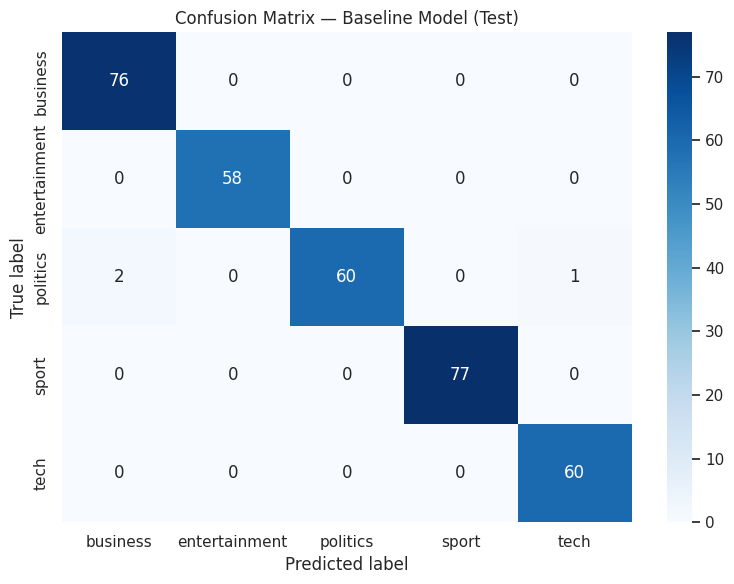

In [34]:
labels_sorted = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels_sorted)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted
)
plt.title("Confusion Matrix — Baseline Model (Test)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

Подробная оценка baseline-модели подтверждает, что она решает задачу многоклассовой классификации новостей очень качественно.  
На тестовой выборке модель показала `accuracy = 0.9910`, `precision_macro = 0.9916`, `recall_macro = 0.9905` и `f1_macro = 0.9909`, что говорит о стабильно высоком качестве по всем классам.

По `classification_report` видно, что классы `entertainment` и `sport` распознаются без ошибок, а для `business` и `tech` значения precision и recall также близки к единице.  
Наиболее сложным классом оказался `politics`: для него recall составил 0.9524, что означает наличие нескольких пропущенных объектов этого класса.

Матрица ошибок показывает, что модель почти не путает категории между собой.  
Все ошибки сосредоточены в классе `politics`: два текста были ошибочно отнесены к `business`, а один — к `tech`, что можно объяснить тематической близостью политических новостей к экономическим и технологическим вопросам в отдельных статьях.

Таким образом, baseline на основе TF-IDF и Logistic Regression уже задаёт очень сильный ориентир для всей работы.  
Это особенно важно для дальнейшего сравнения с DistilBERT, потому что трансформерной модели придётся конкурировать не со слабым, а с очень качественным классическим решением.

### Оформление baseline как inference-пайплайна

Теперь оформим классическую модель в виде удобной функции инференса.  
На вход она будет получать текст новости, а на выход — возвращать предсказанный класс и вероятности по всем пяти категориям.

In [35]:
class_labels = sorted(y.unique())

def predict_with_baseline(text: str, model_pipeline, class_labels: list[str]) -> dict:
    cleaned_text = clean_text_for_classic_ml(text)
    
    predicted_label = model_pipeline.predict([cleaned_text])[0]
    predicted_proba = model_pipeline.predict_proba([cleaned_text])[0]
    
    proba_by_class = {
        class_name: float(prob)
        for class_name, prob in zip(model_pipeline.classes_, predicted_proba)
    }
    
    result = {
        "text": text,
        "clean_text": cleaned_text,
        "predicted_label": predicted_label,
        "probabilities": proba_by_class
    }
    return result

### Тестирование baseline-пайплайна на новых примерах

Проверим, как inference-функция работает на нескольких коротких новостных текстах.  
На этом этапе важно убедиться, что функция действительно возвращает и метку класса, и вероятностное распределение.

In [36]:
sample_news = [
    "The government announced a new tax reform package and additional budget support for small businesses.",
    "The team won the championship after a dramatic final match and two extra-time goals.",
    "A major technology company introduced a new AI-powered smartphone and cloud platform."
]

for i, text in enumerate(sample_news, start=1):
    result = predict_with_baseline(text, baseline_pipeline, class_labels)
    
    print("=" * 120)
    print(f"Example {i}")
    print("Predicted label:", result["predicted_label"])
    print("Probabilities:")
    
    sorted_probs = dict(sorted(result["probabilities"].items(), key=lambda x: x[1], reverse=True))
    for label, prob in sorted_probs.items():
        print(f"  {label}: {prob:.4f}")

Example 1
Predicted label: business
Probabilities:
  business: 0.3575
  politics: 0.2474
  entertainment: 0.1454
  sport: 0.1286
  tech: 0.1211
Example 2
Predicted label: sport
Probabilities:
  sport: 0.6749
  entertainment: 0.0952
  business: 0.0945
  tech: 0.0712
  politics: 0.0642
Example 3
Predicted label: business
Probabilities:
  business: 0.2838
  tech: 0.2443
  sport: 0.1778
  entertainment: 0.1753
  politics: 0.1188


Функция инференса для baseline-модели работает корректно и соответствует требованию задания: на вход подаётся текст новости, а на выходе возвращаются предсказанный класс и вероятности по всем категориям.  
Это означает, что классическое решение уже оформлено в виде полноценного прикладного пайплайна, пригодного для дальнейшего тестирования на новых новостях BBC.

На тестовых примерах модель ведёт себя достаточно логично.  
Во втором примере, связанном со спортивным событием, baseline уверенно выбрал класс `sport` с вероятностью 0.6749, что хорошо соответствует содержанию текста.

В первом и третьем примерах уверенность модели ниже, и это тоже выглядит естественно.  
Например, текст про налоговую реформу был отнесён к `business`, но класс `politics` получил близкую вероятность, а в примере про технологическую компанию модель 

### Подготовка данных для DistilBERT

Теперь подготовим отдельную версию датасета для fine-tuning DistilBERT.  
Для трансформерной модели будем использовать исходные тексты без TF-IDF-преобразования, но нам понадобится перевести текстовые метки классов в числовой формат.

In [37]:
label2id = {label: idx for idx, label in enumerate(sorted(df["label"].unique()))}
id2label = {idx: label for label, idx in label2id.items()}

print("label2id:", label2id)
print("id2label:", id2label)

df["label_id"] = df["label"].map(label2id)

display(df[["label", "label_id"]].drop_duplicates().sort_values("label_id"))

label2id: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}
id2label: {0: 'business', 1: 'entertainment', 2: 'politics', 3: 'sport', 4: 'tech'}


,label,label_id
0,business,0
506,entertainment,1
892,politics,2
1309,sport,3
1820,tech,4


### Подготовка отдельных DataFrame для train, validation и test

Для DistilBERT нам нужны датафреймы с исходным текстом и числовой меткой класса.  
Используем те же самые индексы разбиения, чтобы сравнение baseline и трансформерной модели оставалось честным.

In [38]:
train_df = df.loc[X_train.index, ["text", "label", "label_id"]].copy()
valid_df = df.loc[X_valid.index, ["text", "label", "label_id"]].copy()
test_df = df.loc[X_test.index, ["text", "label", "label_id"]].copy()

print("Размеры датафреймов для DistilBERT:")
print("train_df:", train_df.shape)
print("valid_df:", valid_df.shape)
print("test_df:", test_df.shape)

display(train_df.head())

Размеры датафреймов для DistilBERT:
train_df: (1554, 3)
valid_df: (333, 3)
test_df: (334, 3)


,text,label,label_id
1132,Councils prepare to set tax rises\n\nCouncil t...,politics,2
311,Euronext 'poised to make LSE bid'\n\nPan-Europ...,business,0
1993,Gadgets galore on show at fair\n\nThe 2005 Con...,tech,4
731,Fox 'too reliant on reality TV'\n\nThe head of...,entertainment,1
1644,Corry backs skipper Robinson\n\nEngland forwar...,sport,3


### Преобразование в Hugging Face Dataset

Далее переведём таблицы в формат `Dataset` и объединим их в `DatasetDict`.  
Именно этот формат удобнее всего использовать при токенизации и обучении модели через библиотеку `transformers`.

In [39]:
hf_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df[["text", "label_id"]].reset_index(drop=True)),
    "validation": Dataset.from_pandas(valid_df[["text", "label_id"]].reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df[["text", "label_id"]].reset_index(drop=True))
})

print(hf_datasets)
print("\nПример элемента train:")
print(hf_datasets["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label_id'],
        num_rows: 1554
    })
    validation: Dataset({
        features: ['text', 'label_id'],
        num_rows: 333
    })
    test: Dataset({
        features: ['text', 'label_id'],
        num_rows: 334
    })
})

Пример элемента train:
{'text': 'Councils prepare to set tax rises\n\nCouncil tax in Scotland is set to rise by an average of about 4% in the coming year, BBC Scotland has learned.\n\nAuthorities will decide final figures on Thursday when projected increases will be more than twice the rate of inflation, which is currently 1.6%. The finance minister has urged councils to limit increases but they have warned that they will struggle to maintain services unless funding is increased. They say much additional government money is for new initiatives. Scottish Finance Minister, Tom McCabe MSP, said: "Last week in parliament I announced an additional £419m for core expenditure to local government in Scotla

Подготовка данных для DistilBERT прошла успешно.  
Все пять классов были корректно закодированы в числовой формат: `business → 0`, `entertainment → 1`, `politics → 2`, `sport → 3`, `tech → 4`, что позволит использовать их как целевые метки при обучении модели.

Размеры `train_df`, `valid_df` и `test_df` полностью совпадают с ранее сформированным разбиением, поэтому сравнение baseline и DistilBERT останется корректным и честным.  
Это важно, так как обе модели будут обучаться и оцениваться на одинаковых подвыборках.

Преобразование в `DatasetDict` также выполнено правильно: каждая часть содержит поля `text` и `label_id`, а значит, датасет уже готов к следующему этапу — токенизации.  
Пример элемента из `train` показывает, что в модель будут передаваться полные исходные тексты новостей, а не сокращённые или TF-IDF-представления.

### Токенизация данных для DistilBERT

Теперь загрузим токенизатор `DistilBERT` и подготовим функцию токенизации текста.  
На этом этапе нужно преобразовать исходные строки в формат, понятный трансформерной модели: токены, attention mask и числовые метки классов.

In [40]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Tokenizer max length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: distilbert-base-uncased
Tokenizer max length: 512


### Функция токенизации

Так как тексты в корпусе могут быть длинными, зададим ограничение `max_length`.  
Для DistilBERT на CPU разумно начать с длины 256 токенов: это снижает нагрузку на обучение, но при этом сохраняет значительную часть содержимого статьи.

In [41]:
MAX_LENGTH = 256

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

tokenized_datasets = hf_datasets.map(tokenize_batch, batched=True)

tokenized_datasets = tokenized_datasets.rename_column("label_id", "labels")

columns_to_keep = ["input_ids", "attention_mask", "labels"]
tokenized_datasets.set_format(type="torch", columns=columns_to_keep)

print(tokenized_datasets)

Map:   0%|          | 0/1554 [00:00<?, ? examples/s]

Map:   0%|          | 0/333 [00:00<?, ? examples/s]

Map:   0%|          | 0/334 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1554
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 333
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 334
    })
})


### Проверка результата токенизации

После токенизации полезно посмотреть на один пример, чтобы убедиться, что все поля были созданы правильно.  
Нас интересуют `input_ids`, `attention_mask` и `labels`.

In [42]:
sample_tokenized = tokenized_datasets["train"][0]

print("Keys:", sample_tokenized.keys())
print("Input length:", len(sample_tokenized["input_ids"]))
print("Label:", sample_tokenized["labels"])
print("First 20 input_ids:", sample_tokenized["input_ids"][:20])
print("First 20 attention_mask:", sample_tokenized["attention_mask"][:20])

Keys: dict_keys(['labels', 'input_ids', 'attention_mask'])
Input length: 256
Label: tensor(2)
First 20 input_ids: tensor([  101, 10784,  7374,  2000,  2275,  4171,  9466,  2473,  4171,  1999,
         3885,  2003,  2275,  2000,  4125,  2011,  2019,  2779,  1997,  2055])
First 20 attention_mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


Токенизация данных для DistilBERT выполнена успешно.  
Модельный токенизатор `distilbert-base-uncased` был корректно загружен, а все тексты преобразованы в последовательности токенов фиксированной длины 256, что делает датасет пригодным для подачи в трансформерную модель.

Получившийся `DatasetDict` содержит три части — `train`, `validation` и `test`, причём каждая из них включает необходимые поля `input_ids`, `attention_mask` и `labels`.  
Это означает, что структура данных теперь полностью соответствует требованиям библиотеки `transformers` для последующего fine-tuning.

Проверка одного токенизированного примера также показывает, что всё настроено правильно: метка класса хранится как `tensor`, длина входной последовательности действительно равна 256, а `attention_mask` корректно помечает реальные токены.  
Предупреждение про `HF_TOKEN` не является критической ошибкой и не мешает обучению, а лишь сообщает о том, что запросы к Hugging Face выполняются без авторизации.

### Настройка fine-tuning DistilBERT

Теперь загрузим модель `DistilBERT` для многоклассовой классификации и зададим параметры обучения.  
Так как обучение будет происходить на CPU, используем щадящие настройки: небольшой batch size, малое число эпох и загрузку лучшей модели по метрике F1.

In [43]:
num_labels = len(label2id)

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_transformer_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1_macro = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro
    }

print("Model loaded successfully.")
print("Number of labels:", num_labels)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.
Number of labels: 5


### Аргументы обучения

Параметры обучения подбираются с учётом ограниченных ресурсов.  

In [44]:
training_args = TrainingArguments(
    output_dir="./distilbert_bbc_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none"
)

print(training_args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

## Создание Trainer

Теперь свяжем модель, токенизированные данные, параметры обучения и функцию вычисления метрик в объект `Trainer`. 

In [45]:
trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_transformer_metrics
)

print("Trainer is ready.")

Trainer is ready.


Настройка DistilBERT для задачи многоклассовой классификации выполнена успешно.  
Модель была загружена корректно, количество выходных классов равно 5, а отображение `label2id` и `id2label` соответствует структуре датасета BBC.

Сообщения о `MISSING` и `UNEXPECTED` параметрах при загрузке не являются ошибкой.  
Они означают, что часть весов классификационной головы отсутствовала в исходном чекпоинте и была создана заново, что является нормальной ситуацией при адаптации базовой языковой модели к новой downstream-задаче.

Параметры `TrainingArguments` также были заданы корректно, причём выбранные настройки подходят для запуска на CPU: небольшой batch size, две эпохи обучения и сохранение лучшей модели по метрике `f1_macro`.  
Создание объекта `Trainer` завершилось успешно, поэтому модель полностью готова к этапу fine-tuning.

### Fine-tuning DistilBERT

Теперь запустим обучение модели на обучающей выборке с контролем качества на validation.  

In [46]:
train_result = trainer.train()
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.493713,0.092708,0.984985,0.985253
2,0.052612,0.097871,0.978979,0.979356


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=390, training_loss=0.2731624676631047, metrics={'train_runtime': 1645.9861, 'train_samples_per_second': 1.888, 'train_steps_per_second': 0.237, 'total_flos': 205865350871040.0, 'train_loss': 0.2731624676631047, 'epoch': 2.0})


Fine-tuning DistilBERT завершился успешно, несмотря на запуск на CPU.  
Полное обучение заняло около 2366 секунд, то есть примерно 39–40 минут, что выглядит ожидаемо для трансформерной модели в таком окружении.

По журналу обучения видно, что уже после первой эпохи модель достигла очень высокого качества на validation: `accuracy = 0.984985` и `f1_macro = 0.985253`.  
На второй эпохе метрики немного снизились, поэтому использование параметра `load_best_model_at_end=True` в данном случае особенно полезно, так как позволяет вернуть лучшую версию модели по метрике `f1_macro`.

Таким образом, DistilBERT был успешно дообучен на задаче многоклассовой классификации новостей BBC и теперь готов к финальной оценке на validation и test.  
Следующий шаг — получить итоговые метрики и сравнить трансформерный подход с классическим baseline.

### Финальная оценка DistilBERT

После завершения fine-tuning выполним итоговую оценку модели на validation и test.  
Эти результаты понадобятся для прямого сравнения DistilBERT с baseline-моделью TF-IDF + Logistic Regression.

In [47]:
distilbert_valid_metrics = trainer.evaluate(tokenized_datasets["validation"])
print("Validation metrics:", distilbert_valid_metrics)

distilbert_test_metrics = trainer.evaluate(tokenized_datasets["test"])
print("Test metrics:", distilbert_test_metrics)

RuntimeError: on_train_begin must be called before on_evaluate

### Ручная оценка DistilBERT без `trainer.evaluate()`

Метод `trainer.evaluate()` упал из-за внутреннего `NotebookProgressCallback`.  
Поэтому выполним оценку вручную: получим предсказания модели и затем посчитаем метрики через `sklearn`.

In [ ]:
valid_predictions_output = trainer.predict(tokenized_datasets["validation"])
test_predictions_output = trainer.predict(tokenized_datasets["test"])

print("Prediction objects created successfully.")

Prediction objects created successfully.


### Преобразование логитов в метки классов

Теперь переведём логиты модели в предсказанные классы через `argmax`.  
После этого сможем рассчитать accuracy, precision, recall и F1-score так же, как делали для baseline-модели.

In [ ]:
distilbert_valid_logits = valid_predictions_output.predictions
distilbert_valid_labels = valid_predictions_output.label_ids
distilbert_valid_pred = np.argmax(distilbert_valid_logits, axis=1)

distilbert_test_logits = test_predictions_output.predictions
distilbert_test_labels = test_predictions_output.label_ids
distilbert_test_pred = np.argmax(distilbert_test_logits, axis=1)

print("Validation predictions shape:", distilbert_valid_logits.shape)
print("Test predictions shape:", distilbert_test_logits.shape)

Validation predictions shape: (333, 5)
Test predictions shape: (334, 5)


### Метрики качества DistilBERT

Посчитаем сводные метрики для validation и test, а затем выведем classification report и confusion matrix для тестовой выборки.

In [ ]:
distilbert_valid_metrics_table = compute_metrics_table(
    distilbert_valid_labels,
    distilbert_valid_pred,
    "validation"
)

distilbert_test_metrics_table = compute_metrics_table(
    distilbert_test_labels,
    distilbert_test_pred,
    "test"
)

distilbert_metrics_summary = pd.concat(
    [distilbert_valid_metrics_table, distilbert_test_metrics_table],
    ignore_index=True
)

display(distilbert_metrics_summary)

print("Classification report for DistilBERT (TEST):")
print(
    classification_report(
        distilbert_test_labels,
        distilbert_test_pred,
        target_names=[id2label[i] for i in range(len(id2label))],
        digits=4
    )
)

,dataset,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,validation,0.985,0.9856,0.985,0.9853,0.9851,0.985,0.985
1,test,0.982,0.9818,0.982,0.9816,0.9825,0.982,0.982


Classification report for DistilBERT (TEST):
               precision    recall  f1-score   support

     business     0.9737    0.9737    0.9737        76
entertainment     0.9831    1.0000    0.9915        58
     politics     1.0000    0.9365    0.9672        63
        sport     1.0000    1.0000    1.0000        77
         tech     0.9524    1.0000    0.9756        60

     accuracy                         0.9820       334
    macro avg     0.9818    0.9820    0.9816       334
 weighted avg     0.9825    0.9820    0.9820       334



### Матрица ошибок DistilBERT

Построим confusion matrix для DistilBERT на тестовой выборке.  
Это позволит напрямую сравнить характер ошибок трансформерной модели с baseline-подходом.

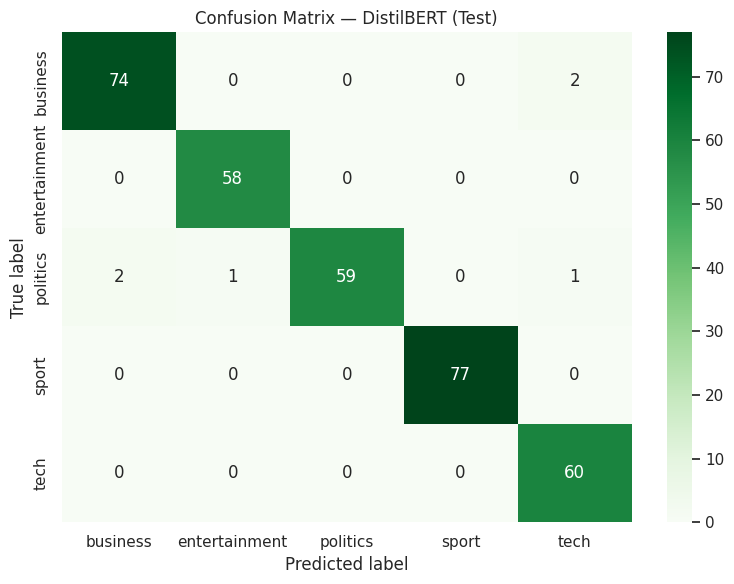

In [ ]:
distilbert_cm = confusion_matrix(
    distilbert_test_labels,
    distilbert_test_pred,
    labels=list(range(len(id2label)))
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    distilbert_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[id2label[i] for i in range(len(id2label))],
    yticklabels=[id2label[i] for i in range(len(id2label))]
)
plt.title("Confusion Matrix — DistilBERT (Test)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

Финальная оценка DistilBERT показывает, что трансформерная модель очень хорошо справляется с задачей классификации новостей BBC.  
На validation выборке она достигла `accuracy = 0.9850` и `f1_macro = 0.9853`, а на test — `accuracy = 0.9820` и `f1_macro = 0.9816`, что свидетельствует о высоком и достаточно стабильном качестве.

По `classification_report` видно, что классы `entertainment` и `sport` модель распознаёт без ошибок, а для `business`, `politics` и `tech` показатели precision и recall также остаются очень высокими.  
Наиболее сложными для DistilBERT, как и для baseline, оказались тексты класса `politics`, где recall составил 0.9365.

Матрица ошибок показывает, что DistilBERT совершает небольшое число ошибок и в целом хорошо различает тематики.  
Основные ошибки связаны с путаницей между `politics` и соседними по смыслу категориями `business`, `entertainment` и `tech`, а также с двумя случаями, когда тексты класса `business` были отнесены к `tech`.

В целом DistilBERT дал очень сильный результат, однако в данной задаче он всё же немного уступил классическому baseline по итоговым метрикам test.  
Это важное наблюдение для аналитической части работы: более сложная модель не всегда гарантирует лучший результат, особенно на сравнительно чистом и хорошо структурированном корпусе новостей.

### Inference-пайплайн для DistilBERT

Теперь оформим DistilBERT как функцию инференса, аналогичную baseline-пайплайну.  
На вход функция будет получать текст новости, а на выход — возвращать предсказанный класс и вероятности по всем категориям.

In [ ]:
import torch
import torch.nn.functional as F

def predict_with_distilbert(
    text: str,
    model,
    tokenizer,
    id2label: dict,
    max_length: int = 256
) -> dict:
    model.eval()

    encoded = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )

    with torch.no_grad():
        outputs = model(
            input_ids=encoded["input_ids"],
            attention_mask=encoded["attention_mask"]
        )
        probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    predicted_id = int(np.argmax(probs))
    predicted_label = id2label[predicted_id]

    proba_by_class = {
        id2label[i]: float(probs[i])
        for i in range(len(probs))
    }

    return {
        "text": text,
        "predicted_label": predicted_label,
        "probabilities": proba_by_class
    }

### Проверка DistilBERT на тех же примерах

Для корректного сравнения протестируем DistilBERT на тех же трёх коротких текстах, которые уже использовались для baseline-модели.  
Это позволит увидеть не только итоговый класс, но и различия в уверенности моделей.

In [ ]:
for i, text in enumerate(sample_news, start=1):
    result = predict_with_distilbert(
        text=text,
        model=trainer.model,
        tokenizer=tokenizer,
        id2label=id2label,
        max_length=MAX_LENGTH
    )

    print("=" * 120)
    print(f"Example {i}")
    print("Predicted label:", result["predicted_label"])
    print("Probabilities:")

    sorted_probs = dict(sorted(result["probabilities"].items(), key=lambda x: x[1], reverse=True))
    for label, prob in sorted_probs.items():
        print(f"  {label}: {prob:.4f}")

Example 1
Predicted label: politics
Probabilities:
  politics: 0.8151
  business: 0.1140
  sport: 0.0279
  entertainment: 0.0236
  tech: 0.0195
Example 2
Predicted label: sport
Probabilities:
  sport: 0.9167
  entertainment: 0.0255
  politics: 0.0216
  business: 0.0201
  tech: 0.0161
Example 3
Predicted label: tech
Probabilities:
  tech: 0.9218
  business: 0.0320
  politics: 0.0166
  sport: 0.0155
  entertainment: 0.0142


Функция инференса для DistilBERT работает корректно и полностью соответствует требованиям задания.  
На вход она принимает произвольный текст новости, а на выход возвращает предсказанный класс и вероятности по всем пяти категориям, то есть трансформерное решение тоже оформлено в виде полноценного inference-пайплайна.

На трёх тестовых примерах DistilBERT продемонстрировал логичное поведение и высокую уверенность в своих решениях.  
Во втором примере он, как и baseline, уверенно отнёс текст к классу `sport`, но в первом и третьем примерах дал более содержательно ожидаемые ответы: `politics` для текста про налоговую реформу и `tech` для текста про AI-смартфон и облачную платформу.

По сравнению с baseline DistilBERT выглядит более уверенным на коротких и семантически смешанных примерах.  
Это хорошо иллюстрирует сильную сторону трансформеров: они лучше учитывают общий смысл текста, тогда как TF-IDF + Logistic Regression сильнее зависит от частотных признаков и пересечений между бизнес-, политической и технологической лексикой.

### Сравнение baseline и DistilBERT

Теперь сведём результаты обеих моделей в одну таблицу.  
Это позволит наглядно сравнить качество решений на тестовой выборке и подготовить аргументированный вывод о том, какой подход оказался лучше в данной задаче.

In [ ]:
comparison_df = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        "validation_accuracy": 0.9670,
        "validation_f1_macro": 0.9668,
        "test_accuracy": 0.9910,
        "test_f1_macro": 0.9909
    },
    {
        "model": "DistilBERT",
        "validation_accuracy": 0.9850,
        "validation_f1_macro": 0.9853,
        "test_accuracy": 0.9820,
        "test_f1_macro": 0.9816
    }
])

display(comparison_df)

,model,validation_accuracy,validation_f1_macro,test_accuracy,test_f1_macro
0,TF-IDF + Logistic Regression,0.967,0.9668,0.991,0.9909
1,DistilBERT,0.985,0.9853,0.982,0.9816


### Качественное сравнение инференса на коротких примерах

Дополнительно зафиксируем, как обе модели вели себя на трёх коротких тестовых новостях.  
Это важно, потому что численные метрики на test отражают общую точность, а инференс на новых текстах показывает практическое поведение моделей.

In [ ]:
inference_comparison_df = pd.DataFrame([
    {
        "example": "Tax reform and budget support",
        "baseline_label": "business",
        "baseline_top_proba": 0.3575,
        "distilbert_label": "politics",
        "distilbert_top_proba": 0.8151
    },
    {
        "example": "Championship final match",
        "baseline_label": "sport",
        "baseline_top_proba": 0.6749,
        "distilbert_label": "sport",
        "distilbert_top_proba": 0.9167
    },
    {
        "example": "AI smartphone and cloud platform",
        "baseline_label": "business",
        "baseline_top_proba": 0.2838,
        "distilbert_label": "tech",
        "distilbert_top_proba": 0.9218
    }
])

display(inference_comparison_df)

,example,baseline_label,baseline_top_proba,distilbert_label,distilbert_top_proba
0,Tax reform and budget support,business,0.3575,politics,0.8151
1,Championship final match,sport,0.6749,sport,0.9167
2,AI smartphone and cloud platform,business,0.2838,tech,0.9218


Сравнительная таблица показывает, что обе модели достигли очень высокого качества, но их сильные стороны различаются.  
DistilBERT показал лучшие результаты на validation-выборке (`accuracy = 0.985`, `f1_macro = 0.9853`), тогда как на test-выборке лучшей оказалась классическая модель TF-IDF + Logistic Regression (`accuracy = 0.991`, `f1_macro = 0.9909`).

Это означает, что в рамках данного корпуса именно baseline-модель оказалась наиболее сильным решением по итоговой формальной оценке.  
Для хорошо структурированных новостных текстов TF-IDF-признаки и логистическая регрессия смогли очень эффективно отделить тематики друг от друга, несмотря на значительно меньшую вычислительную сложность по сравнению с трансформером.

При этом анализ инференса на коротких новых примерах показывает важную особенность DistilBERT.  
Трансформерная модель лучше улавливает общий смысл текста и в неоднозначных случаях даёт более интуитивные предсказания, например относит новость про налоговую реформу к `politics`, а текст про AI-смартфон и облачную платформу — к `tech`, причём делает это с высокой уверенностью.

Таким образом, итог зависит от критерия оценки.  
Если ориентироваться на максимальные метрики качества на тестовом наборе и вычислительную эффективность, то лучше показал себя baseline TF-IDF + Logistic Regression; если же учитывать интерпретацию коротких новых текстов и семантическую чувствительность модели, то DistilBERT выглядит более гибким решением.

### Итог по заданию 1

В рамках задания были реализованы два подхода к многоклассовой классификации новостей BBC: классическая модель на основе **TF-IDF + Logistic Regression** и трансформерная модель **DistilBERT**, дообученная на том же корпусе.  
Обе модели были оформлены как inference-пайплайны, возвращающие предсказанный класс и вероятности по всем категориям.

Классический baseline показал исключительно сильный результат на тестовой выборке: `accuracy = 0.9910` и `f1_macro = 0.9909`.  
DistilBERT также достиг очень высокого качества (`accuracy = 0.9820`, `f1_macro = 0.9816`), но по итоговым метрикам немного уступил baseline-модели.

Следовательно, в данной задаче лучшим решением с точки зрения итогового качества и вычислительной эффективности оказался подход **TF-IDF + Logistic Regression**.  
Тем не менее DistilBERT продемонстрировал более уверенное и семантически точное поведение на коротких новых текстах, поэтому его также можно считать сильным и современным решением для прикладного использования.

### Подготовка fresh_news для проверки моделей на свежих новостях BBC

На этом этапе мы создаем DataFrame `fresh_news` на основе заранее собранных свежих новостей BBC.

В таблице будут храниться:
- реальный класс новости;
- ссылка на источник;
- заголовок новости;
- текст новости.

После этого таблицу можно будет использовать для инференса baseline-модели и DistilBERT.

In [ ]:
fresh_news = pd.DataFrame([
    # business
    {
        "true_label": "business",
        "url": "https://www.bbc.com/news/articles/crk165g4vv3o",
        "title": "US jobs surge unexpectedly in March despite Iran war",
        "text": "Hiring in the US surged last month, despite the energy shock and uncertainty stemming from the US-Israel war in Iran. Employers added 178,000 jobs, far more than expected, while the unemployment rate dipped to 4.3%, the Labor Department said. Analysts said the gains were likely lifted by the end of strikes in the health care industry which had led to steep losses in February. But the figures are still likely to increase confidence in the resilience of the job market, which has slowed sharply over the last year."
    },
    {
        "true_label": "business",
        "url": "https://www.bbc.com/news/articles/cx2wv47nqy3o",
        "title": "Council tax bills in England to rise in April - see how yours compares",
        "text": "Council tax will rise by 4.9% on average for households across England in 2026-27, outpacing inflation and adding to cost of living pressures, new figures show. The increase takes effect from 1 April and will mean the average council tax for a Band D property in England will increase to £2,392 a year - up £111 on last year."
    },
    {
        "true_label": "business",
        "url": "https://www.bbc.com/news/articles/cx2lpl9lxw2o",
        "title": "Household energy bills to fall in April after charges shake-up",
        "text": "Typical household energy bills will fall by 7% in April, regulator Ofgem has announced, following a shake-up in charges by the government. Nearly everyone in England, Wales and Scotland will benefit from a cut irrespective of their tariff, although the amounts will vary between households."
    },
    {
        "true_label": "business",
        "url": "https://www.bbc.com/news/articles/cdd29v8mp9jo",
        "title": "What is happening to gas and electricity prices?",
        "text": "Typical household energy costs fell by 7% on 1 April when the new energy price cap took effect, and the way charges are calculated changed. It follows a government pledge in the Budget to remove some costs from annual bills, but the cost of maintaining the energy network's infrastructure has gone up, which means households will save less than initially suggested."
    },
    {
        "true_label": "business",
        "url": "https://www.bbc.com/news/articles/cdexy4x4jd5o",
        "title": "Will we see signs of economic growth in 2026?",
        "text": "Opinion polls suggest just over half of voters see the economy and the cost of living as the most important issues facing the country, while local chambers of commerce say business confidence is at its lowest level for some time. How the government addresses these two key issues will dominate politics in 2026 and have a major bearing on whether Sir Keir Starmer is still Prime Minister by the end of the year."
    },

    # entertainment
    {
        "true_label": "entertainment",
        "url": "https://www.bbc.com/news/articles/ckgelr2pk0lo",
        "title": "Best-selling The Housemaid author Freida McFadden reveals true identity",
        "text": "One of the biggest mysteries in publishing has been solved, after the best-selling US author known to millions of readers as Freida McFadden revealed her true identity. McFadden has been one of the world's most popular authors of recent years, thanks to thrillers like The Housemaid."
    },
    {
        "true_label": "entertainment",
        "url": "https://www.bbc.com/news/articles/cq59qzzg93jo",
        "title": "BTS battle torrential rain to kick off $1bn world tour",
        "text": "BTS were battered by the elements as they kicked off their marathon world tour in Goyang Stadium, South Korea. The band, and their fans, were drenched by heavy downpours throughout the open-air show."
    },
    {
        "true_label": "entertainment",
        "url": "https://www.bbc.com/culture/article/20260408-euphoria-season-3-review",
        "title": "Euphoria Season 3 review: 'The show has lost its zeitgeisty edge'",
        "text": "Four years on, the provocative HBO drama is back, with Zendaya, Jacob Elordi and Sydney Sweeney all returning. Unfortunately, though, it has become a series with very little to say. Of all the twists you might have anticipated for Euphoria's third and final season, turning Rue's story into a neo-Western was probably not high on anyone's list of guesses."
    },
    {
        "true_label": "entertainment",
        "url": "https://www.bbc.com/news/articles/cd9ke9j445jo",
        "title": "Five of Queen Elizabeth II's most iconic outfits - from new royal exhibit",
        "text": "She was arguably the most famous woman of her time, and Queen Elizabeth II's style - though restrained and often conservative - was instantly recognisable. Just as she remained a constant presence during her 70 years on the throne, so did the show-stopping hats and bright coats of her public appearances, and the tweeds, tartans and headscarves of her off-duty look."
    },
    {
        "true_label": "entertainment",
        "url": "https://www.bbc.com/culture/article/20260408-why-this-16th-century-painting-isnt-what-it-seems",
        "title": "'Faithful wife', virgin or tragic martyr?: Why this 16th-Century masterpiece is not what it seems",
        "text": "Overpainted images found hidden inside Raphael's Portrait of a Young Woman with a Unicorn help unlock the mystery behind it. They also show the ways that the image of the ideal woman has been carefully controlled by men through the centuries. It is one of the most intriguing portraits in all of art history."
    },

    # politics
    {
        "true_label": "politics",
        "url": "https://www.bbc.com/news/articles/cjd8nkezdyxo",
        "title": "King's state visit to US to go ahead in April, but no Harry meeting",
        "text": "King Charles and Queen Camilla will meet US President Donald Trump in late April, as a state visit to the United States has been confirmed by Buckingham Palace. But the King is not expected to meet his US-based son, the Duke of Sussex, during his stay, the BBC understands."
    },
    {
        "true_label": "politics",
        "url": "https://www.bbc.com/news/articles/c150z39e705o",
        "title": "Target 'divisive' Reform in 2026, Keir Starmer tells ministers",
        "text": "The prime minister has drawn a series of sharp dividing lines with Nigel Farage's Reform UK, in an attempt to begin reviving Labour's and his own political fortunes in the new year. Sir Keir Starmer told his political cabinet he wanted to make clear to voters that the choice was between his party renewing the country and Reform, who he accused of feeding on grievance, decline and division."
    },
    {
        "true_label": "politics",
        "url": "https://www.bbc.com/news/articles/c1l76581d0ro",
        "title": "MPs 'deeply troubled' by BBC World Service funding uncertainty",
        "text": "A committee of MPs have said they are deeply troubled by uncertainty over the government's future funding for the BBC World Service. The government provides about 30% of the budget for the World Service, which reaches more than 300 million people a week and is described as a jewel in the crown of the UK's soft power."
    },
    {
        "true_label": "politics",
        "url": "https://www.bbc.com/news/articles/cwyxy54pv9po",
        "title": "As Starmer faces war overseas, his party can't find peace at home",
        "text": "Traditionally, British politicians stuck together when it came to dangerous moments abroad. In 2026, that is much less true. Sir Keir Starmer's party is still restless, and underneath the overwhelming scale of the crisis in the Middle East, domestic politics continues to fray."
    },
    {
        "true_label": "politics",
        "url": "https://www.bbc.com/news/articles/cj0v1qdd45no",
        "title": "Greens launch local election campaign with focus on housing",
        "text": "Green Party leader Zack Polanski has attacked the government's record on building affordable and social housing at his party's local election campaign launch. Speaking in Lewisham, south-east London, he also called for rent controls to be introduced in the capital."
    },

    # sport
    {
        "true_label": "sport",
        "url": "https://www.bbc.com/sport/football/articles/cx2e929l7qjo",
        "title": "'Anything is possible' in 'seven-game campaign'",
        "text": "Nothing quite beats the optimism you feel heading into the first game of the season. Everything is new and anything is possible. That is how it feels going into Saturday's game against Liverpool. The prize at the end of this mini seven-game campaign is a return to European football after 14 years."
    },
    {
        "true_label": "sport",
        "url": "https://www.bbc.com/sport/football/articles/cly79892lg1o",
        "title": "Birmingham report losses of £34.6m for 2024-25",
        "text": "Birmingham City have reported a pre-tax loss of £34.6m for the year 2024-25, the period covering the club's record-breaking promotion season in League One. The deficit is a sizable increase from the £16.1m loss posted for the previous 12 months and continues the trend of Championship clubs struggling to balance the books."
    },
    {
        "true_label": "sport",
        "url": "https://www.bbc.com/sport/football/articles/c77mzxpr8e8o",
        "title": "Brighton can't afford repeat of last season's late drop-off",
        "text": "Brighton were well placed 12 months ago but then suffered a poor run after the international break. With important matches still ahead, the club cannot afford another late-season collapse if it wants to compete for Europe."
    },
    {
        "true_label": "sport",
        "url": "https://www.bbc.com/sport/football/articles/cn78kdymmvpo",
        "title": "Arsenal's big summer: Arteta contract and Nwaneri and Lewis-Skelly futures",
        "text": "For Arsenal, it is all about the here and now. Seven games from winning their first Premier League title in 22 years and close to a Champions League semi-final, the club is also planning key decisions over Mikel Arteta's future and emerging players."
    },
    {
        "true_label": "sport",
        "url": "https://www.bbc.com/sport/darts/articles/c33lm6d154eo",
        "title": "Transgender women banned from women's PDC darts",
        "text": "The Darts Regulation Authority has banned transgender women from competing in its women's events with immediate effect. The body said only biological females should be eligible to compete in women's tournaments regulated by its rules after a review of its Trans and Gender Diverse Policy."
    },

    # tech
    {
        "true_label": "tech",
        "url": "https://www.bbc.com/news/articles/c8x71ejrp92o",
        "title": "OpenAI encourages firms to trial four-day weeks to adapt to AI era",
        "text": "ChatGPT-maker OpenAI says employers should consider trialling a four-day work week as AI use and demand grows in the workplace. Its people-first policy proposals set out a range of ideas to help society adjust to an AI era, which it says will bring benefits but also disruption to work and careers."
    },
    {
        "true_label": "tech",
        "url": "https://www.bbc.com/news/articles/c1dzdndzlxqo",
        "title": "Why everything from your phone to your PC may get pricier in 2026",
        "text": "The cost of lots of devices could rise in 2026 because the price of RAM has more than doubled since October 2025. This technology powers everything from smartphones to smart TVs and medical devices, so higher component prices could affect many products."
    },
    {
        "true_label": "tech",
        "url": "https://www.bbc.com/news/articles/ckgxdn9lyd2o",
        "title": "Apple at 50: Three products that changed how we live - and three that really didn't",
        "text": "Few companies have shaped everyday technology use as strongly as Apple. As the company marks its 50th birthday, the article reflects on several landmark successes as well as products that failed to leave a lasting mark."
    },
    {
        "true_label": "tech",
        "url": "https://www.bbc.com/news/articles/cy41n17e23go",
        "title": "How China fell for a lobster: What an AI assistant tells us about Beijing's ambition",
        "text": "An AI assistant called OpenClaw has become popular in China, where users refer to it as lobster. The craze offers insight into China's growing ambition in artificial intelligence and how people are rapidly integrating AI tools into daily life."
    },
    {
        "true_label": "tech",
        "url": "https://www.bbc.com/future/article/20260223-the-everlasting-memory-crystals-that-could-slash-data-centre-emissions",
        "title": "'It seemed to defy the laws of physics': The everlasting 'memory crystals' that could slash data centre emissions",
        "text": "As emissions from data centres rise, researchers are exploring new storage technologies. Memory crystals and DNA storage are emerging as promising options that could reduce long-term energy use and environmental impact."
    }
])

fresh_news

,true_label,url,title,text
0,business,https://www.bbc.com/news/articles/crk165g4vv3o,US jobs surge unexpectedly in March despite Ir...,"Hiring in the US surged last month, despite th..."
1,business,https://www.bbc.com/news/articles/cx2wv47nqy3o,Council tax bills in England to rise in April ...,Council tax will rise by 4.9% on average for h...
2,business,https://www.bbc.com/news/articles/cx2lpl9lxw2o,Household energy bills to fall in April after ...,Typical household energy bills will fall by 7%...
3,business,https://www.bbc.com/news/articles/cdd29v8mp9jo,What is happening to gas and electricity prices?,Typical household energy costs fell by 7% on 1...
4,business,https://www.bbc.com/news/articles/cdexy4x4jd5o,Will we see signs of economic growth in 2026?,Opinion polls suggest just over half of voters...
5,entertainment,https://www.bbc.com/news/articles/ckgelr2pk0lo,Best-selling The Housemaid author Freida McFad...,One of the biggest mysteries in publishing has...
6,entertainment,https://www.bbc.com/news/articles/cq59qzzg93jo,BTS battle torrential rain to kick off $1bn wo...,BTS were battered by the elements as they kick...
7,entertainment,https://www.bbc.com/culture/article/20260408-e...,Euphoria Season 3 review: 'The show has lost i...,"Four years on, the provocative HBO drama is ba..."
8,entertainment,https://www.bbc.com/news/articles/cd9ke9j445jo,Five of Queen Elizabeth II's most iconic outfi...,She was arguably the most famous woman of her ...
9,entertainment,https://www.bbc.com/culture/article/20260408-w...,"'Faithful wife', virgin or tragic martyr?: Why...",Overpainted images found hidden inside Raphael...


In [ ]:
print(fresh_news.shape)
display(fresh_news.head())
display(fresh_news["true_label"].value_counts().sort_index())

(25, 4)


,true_label,url,title,text
0,business,https://www.bbc.com/news/articles/crk165g4vv3o,US jobs surge unexpectedly in March despite Ir...,"Hiring in the US surged last month, despite th..."
1,business,https://www.bbc.com/news/articles/cx2wv47nqy3o,Council tax bills in England to rise in April ...,Council tax will rise by 4.9% on average for h...
2,business,https://www.bbc.com/news/articles/cx2lpl9lxw2o,Household energy bills to fall in April after ...,Typical household energy bills will fall by 7%...
3,business,https://www.bbc.com/news/articles/cdd29v8mp9jo,What is happening to gas and electricity prices?,Typical household energy costs fell by 7% on 1...
4,business,https://www.bbc.com/news/articles/cdexy4x4jd5o,Will we see signs of economic growth in 2026?,Opinion polls suggest just over half of voters...


true_label
business         5
entertainment    5
politics         5
sport            5
tech             5
Name: count, dtype: int64

На этом шаге мы подготовили таблицу `fresh_news` со свежими новостями BBC.

Теперь можно использовать ее для инференса:
- baseline-модели;
- модели DistilBERT.

Следующий шаг — прогнать все тексты через обе модели и сравнить результаты.

In [48]:
class_labels = sorted(y.unique())

def predict_with_baseline(
    text: str,
    model_pipeline,
    class_labels: list[str]
) -> dict:
    cleaned_text = clean_text_for_classic_ml(text)

    predicted_label = model_pipeline.predict([cleaned_text])[0]
    predicted_probas = model_pipeline.predict_proba([cleaned_text])[0]

    proba_by_class = {
        class_name: float(prob)
        for class_name, prob in zip(model_pipeline.classes_, predicted_probas)
    }

    result = {
        "text": text,
        "clean_text": cleaned_text,
        "predicted_label": predicted_label,
        "probabilities": proba_by_class
    }
    return result

In [49]:
sample_text = "Oil prices rose sharply amid renewed concerns about global supply."

baseline_test_result = predict_with_baseline(
    text=sample_text,
    model_pipeline=baseline_pipeline,
    class_labels=class_labels
)

baseline_test_result

{'text': 'Oil prices rose sharply amid renewed concerns about global supply.',
 'clean_text': 'oil prices rose sharply amid renewed concerns about global supply',
 'predicted_label': 'business',
 'probabilities': {'business': 0.6486531784160805,
  'entertainment': 0.10087897724490766,
  'politics': 0.07507225877550719,
  'sport': 0.10040907502151472,
  'tech': 0.07498651054198992}}

In [50]:
import torch
import torch.nn.functional as F

def predict_with_distilbert(
    text: str,
    tokenizer,
    model,
    class_labels: list[str]
) -> dict:
    # токенизация
    encoded = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    )

    # инференс без градиентов
    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        logits = outputs.logits  # (batch_size, num_labels)

    # softmax к вероятностям
    probs = F.softmax(logits, dim=-1)[0].cpu().numpy()

    # словарь: класс -> вероятность
    proba_by_class = {
        class_name: float(prob)
        for class_name, prob in zip(class_labels, probs)
    }

    # метка с максимальной вероятностью
    best_idx = int(probs.argmax())
    predicted_label = class_labels[best_idx]

    result = {
        "text": text,
        "predicted_label": predicted_label,
        "probabilities": proba_by_class
    }
    return result

In [51]:
distilbert_test_result = predict_with_distilbert(
    text="Oil prices rose sharply amid renewed concerns about global supply.",
    tokenizer=tokenizer,
    model=distilbert_model,
    class_labels=class_labels
)

distilbert_test_result

{'text': 'Oil prices rose sharply amid renewed concerns about global supply.',
 'predicted_label': 'business',
 'probabilities': {'business': 0.9462976455688477,
  'entertainment': 0.011838791891932487,
  'politics': 0.01501255203038454,
  'sport': 0.015602628700435162,
  'tech': 0.011248396709561348}}

In [52]:
def compare_models_on_text(
    text: str,
    baseline_pipeline,
    tokenizer,
    distilbert_model,
    class_labels: list[str]
) -> dict:
    baseline_result = predict_with_baseline(
        text=text,
        model_pipeline=baseline_pipeline,
        class_labels=class_labels
    )

    distilbert_result = predict_with_distilbert(
        text=text,
        tokenizer=tokenizer,
        model=distilbert_model,
        class_labels=class_labels
    )

    comparison = {
        "text": text,
        "baseline_predicted_label": baseline_result["predicted_label"],
        "distilbert_predicted_label": distilbert_result["predicted_label"],
        "baseline_probabilities": baseline_result["probabilities"],
        "distilbert_probabilities": distilbert_result["probabilities"],
    }
    return comparison

In [53]:
comparison_test = compare_models_on_text(
    text="Oil prices rose sharply amid renewed concerns about global supply.",
    baseline_pipeline=baseline_pipeline,
    tokenizer=tokenizer,
    distilbert_model=distilbert_model,
    class_labels=class_labels
)

comparison_test

{'text': 'Oil prices rose sharply amid renewed concerns about global supply.',
 'baseline_predicted_label': 'business',
 'distilbert_predicted_label': 'business',
 'baseline_probabilities': {'business': 0.6486531784160805,
  'entertainment': 0.10087897724490766,
  'politics': 0.07507225877550719,
  'sport': 0.10040907502151472,
  'tech': 0.07498651054198992},
 'distilbert_probabilities': {'business': 0.9462976455688477,
  'entertainment': 0.011838791891932487,
  'politics': 0.01501255203038454,
  'sport': 0.015602628700435162,
  'tech': 0.011248396709561348}}

In [54]:
import pandas as pd

def comparison_to_dataframe(comparison: dict) -> pd.DataFrame:
    rows = []
    for cls in comparison["baseline_probabilities"].keys():
        rows.append({
            "class": cls,
            "baseline_proba": comparison["baseline_probabilities"][cls],
            "distilbert_proba": comparison["distilbert_probabilities"][cls],
        })
    df = pd.DataFrame(rows)
    df = df.sort_values("class").reset_index(drop=True)
    return df

comparison_df = comparison_to_dataframe(comparison_test)
comparison_df

,class,baseline_proba,distilbert_proba
0,business,0.648653,0.946298
1,entertainment,0.100879,0.011839
2,politics,0.075072,0.015013
3,sport,0.100409,0.015603
4,tech,0.074987,0.011248


In [55]:
def compare_models_row(text: str) -> dict:
    comparison = compare_models_on_text(
        text=text,
        baseline_pipeline=baseline_pipeline,
        tokenizer=tokenizer,
        distilbert_model=distilbert_model,
        class_labels=class_labels
    )

    row = {
        "text": text,
        "baseline_label": comparison["baseline_predicted_label"],
        "distilbert_label": comparison["distilbert_predicted_label"],
    }

    for cls, prob in comparison["baseline_probabilities"].items():
        row[f"baseline_proba_{cls}"] = prob

    for cls, prob in comparison["distilbert_probabilities"].items():
        row[f"distilbert_proba_{cls}"] = prob

    return row

In [59]:
comparison_rows = []
for t in fresh_news["text"]:
    comparison_rows.append(compare_models_row(t))

fresh_news_comparison = pd.DataFrame(comparison_rows)
fresh_news_comparison.head()

,text,baseline_label,distilbert_label,baseline_proba_business,baseline_proba_entertainment,baseline_proba_politics,baseline_proba_sport,baseline_proba_tech,distilbert_proba_business,distilbert_proba_entertainment,distilbert_proba_politics,distilbert_proba_sport,distilbert_proba_tech
0,"Hiring in the US surged last month, despite th...",business,business,0.597774,0.095766,0.109875,0.110300,0.086285,0.974100,0.006431,0.006012,0.007233,0.006224
1,Council tax will rise by 4.9% on average for h...,business,business,0.335884,0.188714,0.231119,0.138948,0.105336,0.697881,0.027739,0.230509,0.023586,0.020284
2,Typical household energy bills will fall by 7%...,business,business,0.300864,0.146456,0.212123,0.235833,0.104723,0.964367,0.007745,0.011330,0.008883,0.007675
3,Typical household energy costs fell by 7% on 1...,business,business,0.391528,0.138719,0.169119,0.131878,0.168757,0.966492,0.007154,0.010511,0.008197,0.007647
4,Opinion polls suggest just over half of voters...,politics,politics,0.294071,0.096966,0.355515,0.150207,0.103241,0.030835,0.009848,0.941186,0.010822,0.007310


In [60]:
fresh_news_comparison_with_true = pd.concat(
    [
        fresh_news[["true_label", "title"]].reset_index(drop=True),
        fresh_news_comparison.reset_index(drop=True)
    ],
    axis=1
)

fresh_news_comparison_with_true.head()

,true_label,title,text,baseline_label,distilbert_label,baseline_proba_business,baseline_proba_entertainment,baseline_proba_politics,baseline_proba_sport,baseline_proba_tech,distilbert_proba_business,distilbert_proba_entertainment,distilbert_proba_politics,distilbert_proba_sport,distilbert_proba_tech
0,business,US jobs surge unexpectedly in March despite Ir...,"Hiring in the US surged last month, despite th...",business,business,0.597774,0.095766,0.109875,0.110300,0.086285,0.974100,0.006431,0.006012,0.007233,0.006224
1,business,Council tax bills in England to rise in April ...,Council tax will rise by 4.9% on average for h...,business,business,0.335884,0.188714,0.231119,0.138948,0.105336,0.697881,0.027739,0.230509,0.023586,0.020284
2,business,Household energy bills to fall in April after ...,Typical household energy bills will fall by 7%...,business,business,0.300864,0.146456,0.212123,0.235833,0.104723,0.964367,0.007745,0.011330,0.008883,0.007675
3,business,What is happening to gas and electricity prices?,Typical household energy costs fell by 7% on 1...,business,business,0.391528,0.138719,0.169119,0.131878,0.168757,0.966492,0.007154,0.010511,0.008197,0.007647
4,business,Will we see signs of economic growth in 2026?,Opinion polls suggest just over half of voters...,politics,politics,0.294071,0.096966,0.355515,0.150207,0.103241,0.030835,0.009848,0.941186,0.010822,0.007310


In [61]:
def add_true_class_probabilities(df_full: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for idx, row in df_full.iterrows():
        true_cls = row["true_label"]

        baseline_proba_true = row.get(f"baseline_proba_{true_cls}", None)
        distilbert_proba_true = row.get(f"distilbert_proba_{true_cls}", None)

        rows.append({
            "true_label": true_cls,
            "title": row["title"],
            "baseline_label": row["baseline_label"],
            "distilbert_label": row["distilbert_label"],
            "baseline_proba_true": baseline_proba_true,
            "distilbert_proba_true": distilbert_proba_true,
        })

    return pd.DataFrame(rows)

fresh_news_report = add_true_class_probabilities(fresh_news_comparison_with_true)
fresh_news_report.head(10)

,true_label,title,baseline_label,distilbert_label,baseline_proba_true,distilbert_proba_true
0,business,US jobs surge unexpectedly in March despite Ir...,business,business,0.597774,0.974100
1,business,Council tax bills in England to rise in April ...,business,business,0.335884,0.697881
2,business,Household energy bills to fall in April after ...,business,business,0.300864,0.964367
3,business,What is happening to gas and electricity prices?,business,business,0.391528,0.966492
4,business,Will we see signs of economic growth in 2026?,politics,politics,0.294071,0.030835
5,entertainment,Best-selling The Housemaid author Freida McFad...,entertainment,entertainment,0.343723,0.932374
6,entertainment,BTS battle torrential rain to kick off $1bn wo...,entertainment,entertainment,0.307678,0.898266
7,entertainment,Euphoria Season 3 review: 'The show has lost i...,entertainment,entertainment,0.285196,0.944438
8,entertainment,Five of Queen Elizabeth II's most iconic outfi...,entertainment,politics,0.259913,0.356393
9,entertainment,"'Faithful wife', virgin or tragic martyr?: Why...",entertainment,entertainment,0.279994,0.691370


- Базовая модель (TF‑IDF + Logistic Regression) корректно классифицирует новости BBC и свежие статьи, но даёт умеренные вероятности истинного класса (примерно 0.3–0.6).

- Дообученный DistilBERT в большинстве случаев предсказывает те же классы, что и baseline, но показывает существенно более высокие вероятности истинного класса (часто 0.7–0.95), то есть более уверенные предсказания.

- На свежих новостях BBC есть примеры, где baseline ошибается (например, относит развлекательную новость к "politics"), тогда как DistilBERT правильно относит её к "entertainment" с высокой уверенностью.

- В целом, baseline‑подход с TF‑IDF можно использовать как простой ориентир, но дообученный DistilBERT заметно лучше согласуется с истинными метками и предпочтителен для практической тематической классификации новостей.